# Evaluation: confusion matrix & classification report

In [1]:
!pip install torch==2.1.1
!pip install dgl -f https://data.dgl.ai/wheels/torch-2.1/cu121/repo.html
!pip install scikit-learn
!pip install fasttext==0.9.2

Looking in indexes: https://artifactory.tcsbank.ru/artifactory/api/pypi/python-all/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.2/670.2 MB 12.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 113.7 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 71.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 120.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 51.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 143.5 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 13.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 20.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 56.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 94.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━

In [29]:

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report

from process.EventProcess import EventProcess
from prepare_data import prepare_for_graphormer
from core.model.MainModel import MainModel
from helper.logger import get_logger

device = 'cuda' if torch.cuda.is_available() else 'cpu'

args = SimpleNamespace(**{
    'dataset': 'gaia',
    'labels_file': 'label_15_85.csv',
    'embedding_dim': 128,
    'graph_hidden': 128,
    'graph_out': 32,
    'num_heads': 16,
    'num_layers': 2,
    'linear_hidden': [64],
    'attn_drop': 0.0,
    'aug_percent': 0.0,
    'N_I': 10,
    'N_T': 5,
    'TO': True,
    'CM': True,
    'guide_weight': 0.1,
    'temperature': 0.3,
    'dynamic_weight': True,
    'batch_size': 1,
    'reconstruct': True,
})

logger = get_logger('logs/gaia', 'eval-report')

def collate(samples):
    graphs, labels = map(list, zip(*samples))
    labels = torch.tensor(labels)
    return prepare_for_graphormer(graphs, labels)

processor = EventProcess(args, logger)
_, test_data = processor.process(reconstruct=args.reconstruct)
test_loader = DataLoader(test_data, batch_size=args.batch_size, shuffle=False, collate_fn=collate)
nodes = processor.nodes
types = processor.types

logger.info(f'Test samples: {len(test_data)}')


2026-03-17 14:25:28 [INFO]: Load raw events from gaia dataset
2026-03-17 14:25:32 [INFO]: Build embedding for raw events


Read 0M words
Number of words:  952
Number of labels: 26
Progress: 100.0% words/sec/thread:   29099 lr:  0.000000 avg.loss:  1.169894 ETA:   0h 0m 0s
Read 0M words
Number of words:  952
Number of labels: 26
Progress: 100.0% words/sec/thread:   33843 lr:  0.000000 avg.loss:  0.936525 ETA:   0h 0m 0s
Read 0M words
Number of words:  45
Number of labels: 26
Progress: 100.0% words/sec/thread:   14505 lr:  0.000000 avg.loss:  0.866384 ETA:   0h 0m 0s
Read 0M words
Number of words:  45
Number of labels: 26
Progress: 100.0% words/sec/thread:   13311 lr:  0.000000 avg.loss:  0.910010 ETA:   0h 0m 0s
Read 0M words
Number of words:  107
Number of labels: 26
Progress: 100.0% words/sec/thread:   19307 lr:  0.000000 avg.loss:  0.725689 ETA:   0h 0m 0s
Read 0M words
Number of words:  107
Number of labels: 26
Progress: 100.0% words/sec/thread:   18293 lr:  0.000000 avg.loss:  0.759619 ETA:   0h 0m 0s


2026-03-17 14:25:58 [INFO]: Build dataset for training
2026-03-17 14:26:14 [INFO]: Test samples: 13774


In [30]:

model = MainModel(args).to(device)
ckpt_path = 'logs/gaia/TransTVDiag.pt'
if os.path.exists(ckpt_path):
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state['model'])
    logger.info(f'Loaded checkpoint: {ckpt_path}')
else:
    logger.warning('Checkpoint not found; using randomly initialized model')
model.eval()


2026-03-17 14:26:24 [INFO]: Loaded checkpoint: logs/gaia/TransTVDiag.pt


MainModel(
  (metric_encoder): Encoder(
    (graph_encoder): GraphormerEncoder(
      (dropout): Dropout(p=0.0, inplace=False)
      (graph_token): Embedding(1, 128)
      (degree_encoder): DegreeEncoder(
        (encoder1): Embedding(513, 128, padding_idx=0)
        (encoder2): Embedding(513, 128, padding_idx=0)
      )
      (path_encoder): PathEncoder(
        (embedding_table): Embedding(80, 1)
      )
      (spatial_encoder): SpatialEncoder(
        (embedding_table): Embedding(513, 16, padding_idx=0)
      )
      (graph_token_virtual_distance): Embedding(1, 16)
      (emb_layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (layers): ModuleList(
        (0-1): 2 x GraphormerLayerWithAttn(
          (attn): BiasedMHAWithAttn(
            (q_proj): Linear(in_features=128, out_features=128, bias=True)
            (k_proj): Linear(in_features=128, out_features=128, bias=True)
            (v_proj): Linear(in_features=128, out_features=128, bias=True)
            (

In [31]:
root_true, root_pred = [], []
type_true, type_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        labels, metric_feat, trace_feat, log_feat, in_deg, out_deg, attn_mask, path_data, dist = batch
        labels = labels.to(device)
        metric_feat = metric_feat.to(device)
        trace_feat = trace_feat.to(device)
        log_feat = log_feat.to(device)
        in_deg, out_deg = in_deg.to(device), out_deg.to(device)
        attn_mask, path_data, dist = attn_mask.to(device), path_data.to(device), dist.to(device)

        (_, _, _), root_logit, type_logit = model(
            metric_feat, trace_feat, log_feat,
            in_deg, out_deg, dist, path_data, attn_mask=attn_mask, return_attn=False,
        )

        root_true.append(labels[0,0].item())
        type_true.append(labels[0,1].item())
        root_pred.append(torch.argmax(root_logit, dim=-1).item())
        type_pred.append(torch.argmax(type_logit, dim=-1).item())

root_true = np.array(root_true)
root_pred = np.array(root_pred)
type_true = np.array(type_true)
type_pred = np.array(type_pred)

# human-readable names
root_true_names = [nodes[i] for i in root_true]
root_pred_names = [nodes[i] for i in root_pred]
type_true_names = [types[i] for i in type_true]
type_pred_names = [types[i] for i in type_pred]

logger.info('Inference complete')
logger.info(f'Root acc: {(root_true==root_pred).mean():.3f}, Type acc: {(type_true==type_pred).mean():.3f}')


2026-03-17 14:28:22 [INFO]: Inference complete
2026-03-17 14:28:22 [INFO]: Root acc: 0.485, Type acc: 0.947


In [32]:
import pandas as pd
save_path = 'logs/gaia/predictions_eval.csv'

records = []
for idx in range(len(root_true)):
    records.append({
        'sample_idx': idx,
        'true_root_idx': int(root_true[idx]),
        'true_root_name': root_true_names[idx],
        'pred_root_idx': int(root_pred[idx]),
        'pred_root_name': root_pred_names[idx],
        'true_type_idx': int(type_true[idx]),
        'true_type_name': type_true_names[idx],
        'pred_type_idx': int(type_pred[idx]),
        'pred_type_name': type_pred_names[idx],
    })

pd.DataFrame(records).to_csv(save_path, index=False)
logger.info(f'Saved predictions to {save_path}')

2026-03-17 14:28:57 [INFO]: Saved predictions to logs/gaia/predictions_eval.csv


In [33]:
pred_res_df = pd.read_csv('logs/gaia/predictions_eval.csv')
pred_res_df.head()

,sample_idx,true_root_idx,true_root_name,pred_root_idx,pred_root_name,true_type_idx,true_type_name,pred_type_idx,pred_type_name
0,0,4,mobservice1,5,mobservice2,2,[normal memory freed label],2,[normal memory freed label]
1,1,5,mobservice2,5,mobservice2,2,[normal memory freed label],2,[normal memory freed label]
2,2,4,mobservice1,4,mobservice1,2,[normal memory freed label],2,[normal memory freed label]
3,3,4,mobservice1,4,mobservice1,2,[normal memory freed label],2,[normal memory freed label]
4,4,5,mobservice2,4,mobservice1,2,[normal memory freed label],2,[normal memory freed label]


In [34]:
def value_counts_with_percentages(series, dropna=False, decimals=2):
    counts = series.value_counts(dropna=dropna)
    percents = (series.value_counts(normalize=True, dropna=dropna) * 100).round(decimals)
    return pd.DataFrame({
        'count': counts,
        'percent': percents
    })
value_counts_with_percentages(pred_res_df['true_root_name'])

,count,percent
true_root_name,,
mobservice2,6637,48.18
mobservice1,6626,48.11
dbservice2,87,0.63
webservice1,78,0.57
webservice2,76,0.55
dbservice1,69,0.50
logservice1,55,0.40
logservice2,51,0.37
redisservice2,48,0.35


In [35]:
value_counts_with_percentages(pred_res_df['pred_root_name'])

,count,percent
pred_root_name,,
mobservice2,10748,78.03
mobservice1,2985,21.67
redisservice2,16,0.12
dbservice2,9,0.07
webservice2,8,0.06
dbservice1,8,0.06


In [36]:
value_counts_with_percentages(pred_res_df['true_type_name'])

,count,percent
true_type_name,,
[normal memory freed label],13143,95.42
[login failure],564,4.09
[memory_anomalies],37,0.27
[file moving program],15,0.11
normal,15,0.11


2026-03-17 14:29:18 [DEBUG]: locator: <matplotlib.ticker.AutoLocator object at 0x7f73930d9630>


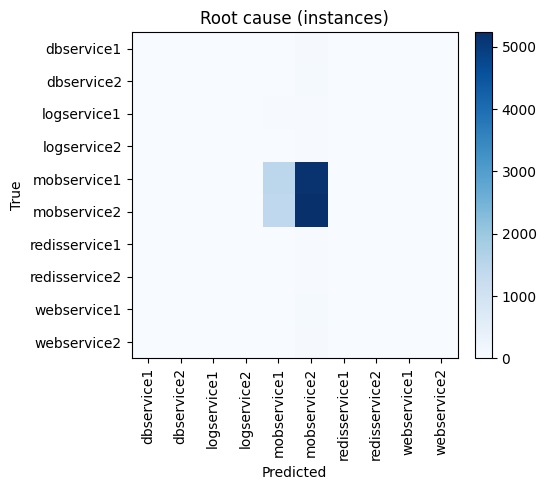

2026-03-17 14:29:18 [DEBUG]: locator: <matplotlib.ticker.AutoLocator object at 0x7f7392f55d20>


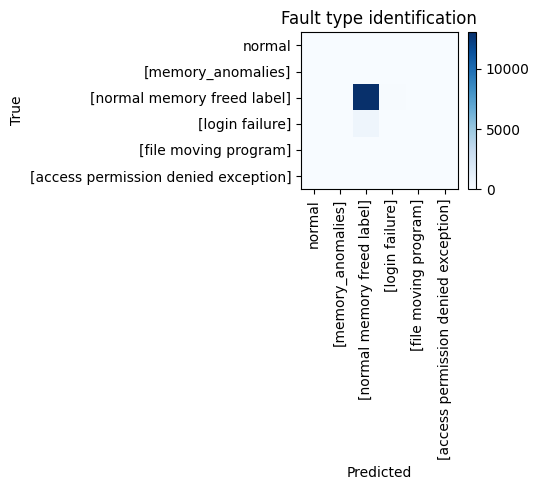

In [37]:

def plot_cm(cm, labels, title):
    fig, ax = plt.subplots(figsize=(6,5))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90)
    ax.set_yticklabels(labels)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

cm_root = confusion_matrix(root_true, root_pred, labels=list(range(len(nodes))))
cm_type = confusion_matrix(type_true, type_pred, labels=list(range(len(types))))

plot_cm(cm_root, nodes, 'Root cause (instances)')
plot_cm(cm_type, types, 'Fault type identification')


In [38]:
print('Root cause classification report')
print(classification_report(root_true_names, root_pred_names, zero_division=0))

print('Fault type classification report')
print(classification_report(type_true_names, type_pred_names, zero_division=0))


Root cause classification report
               precision    recall  f1-score   support

   dbservice1       0.00      0.00      0.00        69
   dbservice2       0.00      0.00      0.00        87
  logservice1       0.00      0.00      0.00        55
  logservice2       0.00      0.00      0.00        51
  mobservice1       0.49      0.22      0.30      6626
  mobservice2       0.49      0.79      0.60      6637
redisservice1       0.00      0.00      0.00        47
redisservice2       0.06      0.02      0.03        48
  webservice1       0.00      0.00      0.00        78
  webservice2       0.00      0.00      0.00        76

     accuracy                           0.49     13774
    macro avg       0.10      0.10      0.09     13774
 weighted avg       0.47      0.49      0.44     13774

Fault type classification report
                             precision    recall  f1-score   support

      [file moving program]       0.00      0.00      0.00        15
            [login fai